#EcoType: Forest Cover Type Prediction Using Machine Learning:
#Data Cleaning & Preprocess
#https://colab.research.google.com/drive/12LEr0FjbpqghRQspbRURvgMSlC--42rD?authuser=1
#Data-Visualization
#https://colab.research.google.com/drive/14i5b_vq4cymamTJUMLn88KmdWq4yfAZw?authuser=1
# Machine Learning-Models
#https://colab.research.google.com/drive/14Ll2j98tQcbdj2NJFEY6b9ig0LNrL4WI?authuser=1
#Streamlit-App
#https://colab.research.google.com/drive/1H5DE1SCKhZ6Ohyr_hPCNTsJwY-ALU0j_?authuser=1#scrollTo=0E2BgNq-5gS-

In [ ]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
%matplotlib inline
import warnings
warnings.filterwarnings('ignore')

In [ ]:
!pip install catboost

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 97.1/97.1 MB 8.0 MB/s eta 0:00:00


In [ ]:
# Basic Import
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
# Modelling
from sklearn.metrics import mean_squared_error, r2_score
from sklearn.neighbors import KNeighborsRegressor
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor,AdaBoostRegressor
from sklearn.svm import SVR
from sklearn.linear_model import LinearRegression, Ridge,Lasso
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error
from sklearn.model_selection import RandomizedSearchCV
from catboost import CatBoostRegressor
from xgboost import XGBRegressor
import warnings

In [ ]:
!pip install gdown

In [ ]:
import gdown

file_id = "1UzSSMGF9iqSb8YnSRXMt02v3uf9ZUOf6"
url = f"https://drive.google.com/uc?id={file_id}"

gdown.download(url, "data.csv", quiet=False)

Downloading...
From: https://drive.google.com/uc?id=1UzSSMGF9iqSb8YnSRXMt02v3uf9ZUOf6
To: /content/data.csv
100%|██████████| 8.49M/8.49M [00:00<00:00, 55.9MB/s]


'data.csv'

In [ ]:
import pandas as pd

df = pd.read_csv("data.csv")
df.head()

,Elevation,Aspect,Slope,Horizontal_Distance_To_Hydrology,Vertical_Distance_To_Hydrology,Horizontal_Distance_To_Roadways,Hillshade_9am,Hillshade_Noon,Hillshade_3pm,Horizontal_Distance_To_Fire_Points,Cover_Type,Wilderness_Area,Soil_Type
0,2596,51,3,258,0,510,221,232,148,6279,Aspen,1,29
1,2590,56,2,212,-6,390,220,235,151,6225,Aspen,1,29
2,2804,139,9,268,65,3180,234,238,135,6121,Lodgepole Pine,1,12
3,2785,155,18,242,118,3090,238,238,122,6211,Lodgepole Pine,1,30
4,2595,45,2,153,-1,391,220,234,150,6172,Aspen,1,29


In [ ]:
import pandas as pd

url = "https://drive.google.com/uc?id=1UzSSMGF9iqSb8YnSRXMt02v3uf9ZUOf6"
df = pd.read_csv(url)
df.head()

,Elevation,Aspect,Slope,Horizontal_Distance_To_Hydrology,Vertical_Distance_To_Hydrology,Horizontal_Distance_To_Roadways,Hillshade_9am,Hillshade_Noon,Hillshade_3pm,Horizontal_Distance_To_Fire_Points,Cover_Type,Wilderness_Area,Soil_Type
0,2596,51,3,258,0,510,221,232,148,6279,Aspen,1,29
1,2590,56,2,212,-6,390,220,235,151,6225,Aspen,1,29
2,2804,139,9,268,65,3180,234,238,135,6121,Lodgepole Pine,1,12
3,2785,155,18,242,118,3090,238,238,122,6211,Lodgepole Pine,1,30
4,2595,45,2,153,-1,391,220,234,150,6172,Aspen,1,29


In [ ]:
df.columns

Index(['Elevation', 'Aspect', 'Slope', 'Horizontal_Distance_To_Hydrology',
       'Vertical_Distance_To_Hydrology', 'Horizontal_Distance_To_Roadways',
       'Hillshade_9am', 'Hillshade_Noon', 'Hillshade_3pm',
       'Horizontal_Distance_To_Fire_Points', 'Cover_Type', 'Wilderness_Area',
       'Soil_Type'],
      dtype='object')

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
!cp data.csv /content/drive/MyDrive/

In [ ]:
df.rename(columns={
    "Elevation": "elevation",
    "Aspect": "aspect",
    "Slope": "slope",
    "Horizontal_Distance_To_Hydrology": "hor_dis_hydrology",
    "Vertical_Distance_To_Hydrology": "ver_dis_hydrology",
    "Horizontal_Distance_To_Roadways": "hor_dis_roadways",
    "Hillshade_9am": "hillshade_9am",
    "Hillshade_Noon": "hillshade_noon",
    "Hillshade_3pm": "hillshade_3pm",
    "Horizontal_Distance_To_Fire_Points": "hor_dis_fire_points",
    "Cover_Type": "cover_type",
    "Wilderness_Area": "wilderness_area",
    "Soil_Type": "soil_type"
}, inplace=True)

In [ ]:
df.head()

,elevation,aspect,slope,hor_dis_hydrology,ver_dis_hydrology,hor_dis_roadways,hillshade_9am,hillshade_noon,hillshade_3pm,hor_dis_fire_points,cover_type,wilderness_area,soil_type
0,2596,51,3,258,0,510,221,232,148,6279,Aspen,1,29
1,2590,56,2,212,-6,390,220,235,151,6225,Aspen,1,29
2,2804,139,9,268,65,3180,234,238,135,6121,Lodgepole Pine,1,12
3,2785,155,18,242,118,3090,238,238,122,6211,Lodgepole Pine,1,30
4,2595,45,2,153,-1,391,220,234,150,6172,Aspen,1,29


In [ ]:
df.tail()

,elevation,aspect,slope,hor_dis_hydrology,ver_dis_hydrology,hor_dis_roadways,hillshade_9am,hillshade_noon,hillshade_3pm,hor_dis_fire_points,cover_type,wilderness_area,soil_type
145885,2834,88,8,376,44,2552,232,227,128,1595,Lodgepole Pine,1,29
145886,2832,68,4,390,44,2522,224,231,142,1572,Lodgepole Pine,1,29
145887,2829,80,7,390,33,2492,229,228,133,1550,Lodgepole Pine,1,29
145888,2826,121,7,379,30,2462,232,234,135,1528,Lodgepole Pine,1,29
145889,2823,132,12,371,27,2432,239,234,123,1506,Lodgepole Pine,1,1


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 145890 entries, 0 to 145889
Data columns (total 13 columns):
 #   Column               Non-Null Count   Dtype 
---  ------               --------------   ----- 
 0   elevation            145890 non-null  int64 
 1   aspect               145890 non-null  int64 
 2   slope                145890 non-null  int64 
 3   hor_dis_hydrology    145890 non-null  int64 
 4   ver_dis_hydrology    145890 non-null  int64 
 5   hor_dis_roadways     145890 non-null  int64 
 6   hillshade_9am        145890 non-null  int64 
 7   hillshade_noon       145890 non-null  int64 
 8   hillshade_3pm        145890 non-null  int64 
 9   hor_dis_fire_points  145890 non-null  int64 
 10  cover_type           145890 non-null  object
 11  wilderness_area      145890 non-null  int64 
 12  soil_type            145890 non-null  int64 
dtypes: int64(12), object(1)
memory usage: 14.5+ MB


In [ ]:
df.shape

(145890, 13)

In [ ]:
df.isnull().sum()

,0
elevation,0
aspect,0
slope,0
hor_dis_hydrology,0
ver_dis_hydrology,0
hor_dis_roadways,0
hillshade_9am,0
hillshade_noon,0
hillshade_3pm,0
hor_dis_fire_points,0


In [ ]:
df.describe()

,elevation,aspect,slope,hor_dis_hydrology,ver_dis_hydrology,hor_dis_roadways,hillshade_9am,hillshade_noon,hillshade_3pm,hor_dis_fire_points,wilderness_area,soil_type
count,145890.000000,145890.000000,145890.000000,145890.000000,145890.000000,145890.000000,145890.000000,145890.000000,145890.000000,145890.000000,145890.000000,145890.000000
mean,2874.458949,141.127418,11.925574,251.824738,34.554322,3313.827541,217.368106,224.874748,139.788203,3044.958105,1.186593,23.364905
std,210.801279,107.719296,6.319326,192.473899,41.215776,1687.779953,21.590298,16.084851,31.311690,1761.882341,0.656571,8.215184
min,1863.000000,0.000000,0.000000,0.000000,-146.000000,0.000000,0.000000,99.000000,0.000000,0.000000,1.000000,1.000000
25%,2747.000000,54.000000,7.000000,95.000000,7.000000,1848.000000,207.000000,216.000000,121.000000,1608.000000,1.000000,12.000000
50%,2909.000000,108.000000,11.000000,212.000000,23.000000,3420.000000,222.000000,226.000000,140.000000,2713.000000,1.000000,29.000000
75%,3004.000000,217.000000,15.000000,362.000000,51.000000,4673.000000,232.000000,236.000000,159.000000,4478.000000,1.000000,29.000000
max,3849.000000,360.000000,61.000000,1343.000000,554.000000,7117.000000,254.000000,254.000000,248.000000,7173.000000,4.000000,40.000000


In [ ]:
numeric_features = [feature for feature in df.columns if df[feature].dtype != 'O']
categorical_features = [feature for feature in df.columns if df[feature].dtype == 'O']

In [ ]:
# print columns
print('We have {} numerical features : {}'.format(len(numeric_features), numeric_features))
print('\nWe have {} categorical features : {}'.format(len(categorical_features), categorical_features))

We have 12 numerical features : ['elevation', 'aspect', 'slope', 'hor_dis_hydrology', 'ver_dis_hydrology', 'hor_dis_roadways', 'hillshade_9am', 'hillshade_noon', 'hillshade_3pm', 'hor_dis_fire_points', 'wilderness_area', 'soil_type']

We have 1 categorical features : ['cover_type']


In [ ]:
df["soil_type"].unique()

array([29, 12, 30, 18, 16, 20, 24, 23, 40, 19,  8, 22, 39,  9, 38, 33, 31,
       32, 11, 10,  5, 28,  4,  1, 13,  2, 17,  3, 34,  6, 14, 37, 35, 36,
       21, 26, 27, 25,  7])

In [ ]:
df["soil_type"].value_counts()

,count
soil_type,
29,60696
12,29144
30,18158
23,10150
20,6098
16,2219
24,2169
10,2142
18,1829


In [ ]:
df["cover_type"].unique()

array(['Aspen', 'Lodgepole Pine', 'Spruce/Fir', 'Krummholz',
       'Ponderosa Pine', 'Douglas-fir', 'Cottonwood/Willow'], dtype=object)

In [ ]:
df["cover_type"].value_counts()

,count
cover_type,
Lodgepole Pine,103071
Spruce/Fir,31110
Aspen,3069
Krummholz,2160
Ponderosa Pine,2160
Douglas-fir,2160
Cottonwood/Willow,2160


In [ ]:
df['cover_type'].value_counts(normalize=True) * 100

,proportion
cover_type,
Lodgepole Pine,70.649805
Spruce/Fir,21.324285
Aspen,2.103640
Krummholz,1.480568
Ponderosa Pine,1.480568
Douglas-fir,1.480568
Cottonwood/Willow,1.480568


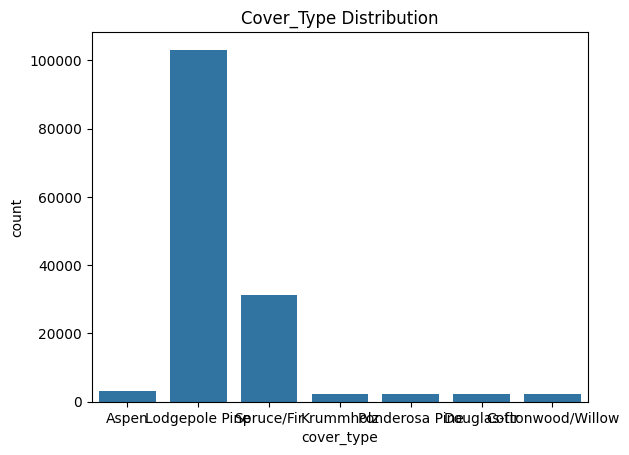

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt

sns.countplot(x='cover_type', data=df)
plt.title("Cover_Type Distribution")
plt.show()

In [ ]:
df.duplicated().any()

np.False_

In [ ]:
df.duplicated().sum()

np.int64(0)

In [ ]:
df[df.duplicated()]

,elevation,aspect,slope,hor_dis_hydrology,ver_dis_hydrology,hor_dis_roadways,hillshade_9am,hillshade_noon,hillshade_3pm,hor_dis_fire_points,cover_type,wilderness_area,soil_type


In [ ]:
df.columns

Index(['elevation', 'aspect', 'slope', 'hor_dis_hydrology',
       'ver_dis_hydrology', 'hor_dis_roadways', 'hillshade_9am',
       'hillshade_noon', 'hillshade_3pm', 'hor_dis_fire_points', 'cover_type',
       'wilderness_area', 'soil_type'],
      dtype='object')

In [ ]:
df.isnull().sum()

,0
elevation,0
aspect,0
slope,0
hor_dis_hydrology,0
ver_dis_hydrology,0
hor_dis_roadways,0
hillshade_9am,0
hillshade_noon,0
hillshade_3pm,0
hor_dis_fire_points,0


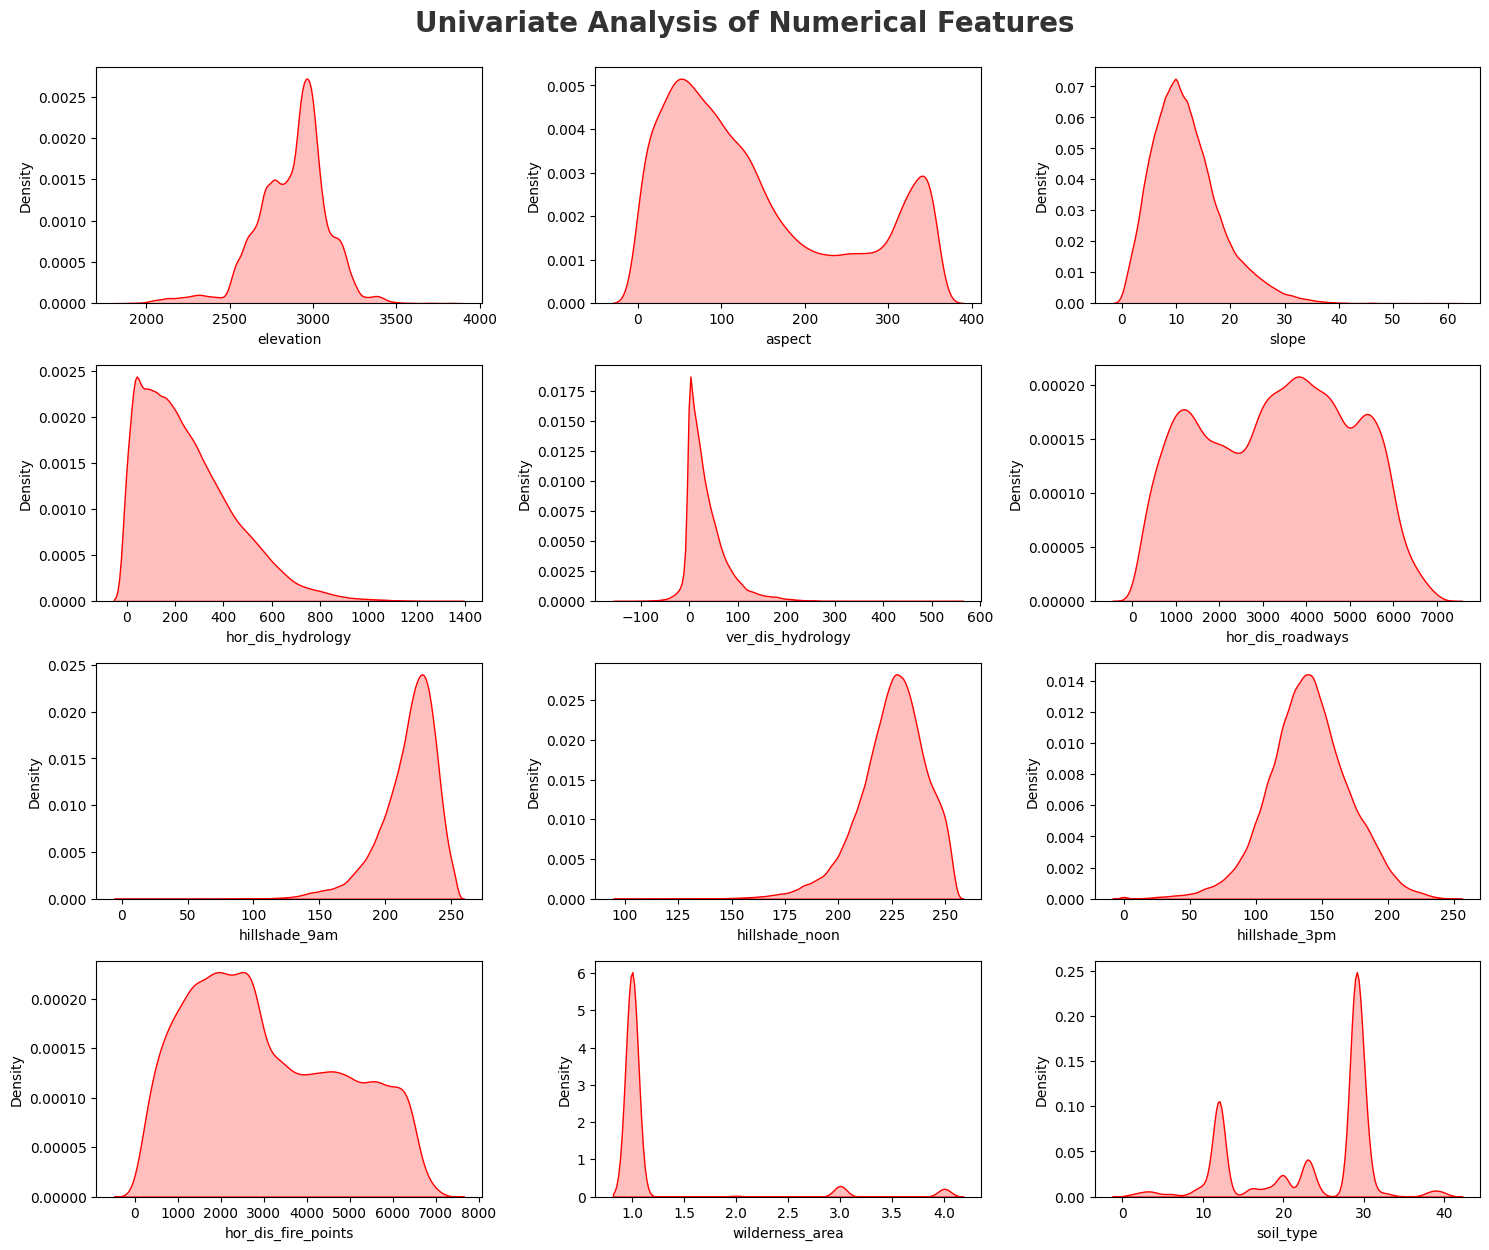

In [ ]:
# Proportion of count data on numerical columns

plt.figure(figsize=(15, 15))
plt.suptitle('Univariate Analysis of Numerical Features', fontsize=20, fontweight='bold', alpha=0.8, y=1.)

for i in range(0, len(numeric_features)):
    plt.subplot(5, 3, i+1)
    sns.kdeplot(x=df[numeric_features[i]], shade=True, color='r')
    plt.xlabel(numeric_features[i])
    plt.tight_layout()

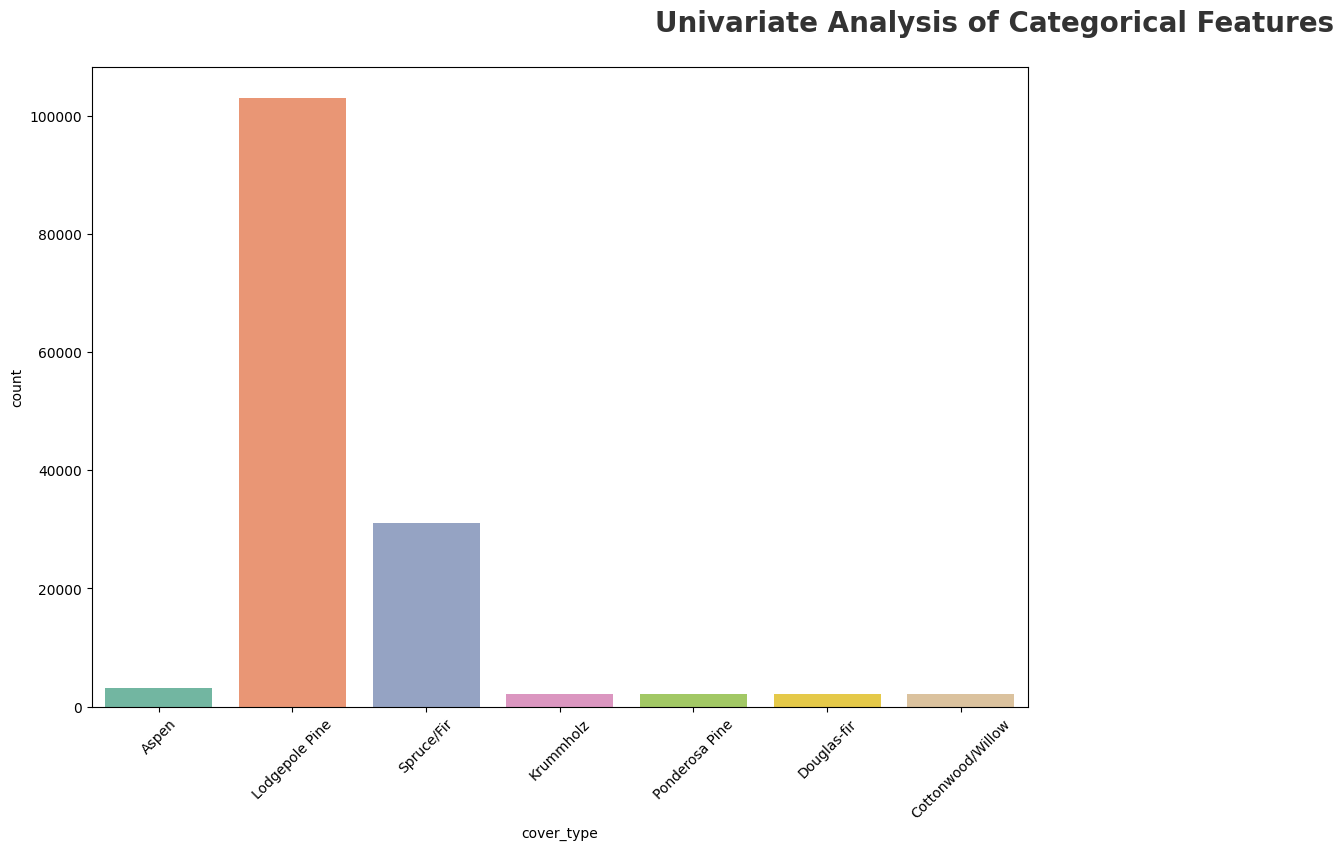

In [ ]:
# categorical columns
plt.figure(figsize=(20, 15))
plt.suptitle('Univariate Analysis of Categorical Features', fontsize=20, fontweight='bold', alpha=0.8, y=1.)
category = ['cover_type']
for i in range(0, len(category)):
    plt.subplot(2, 2, i+1)
    sns.countplot(x=df[category[i]],palette="Set2")
    plt.xlabel(category[i])
    plt.xticks(rotation=45)
    plt.tight_layout()

In [ ]:
cols =  ['elevation', 'aspect', 'slope', 'hor_dis_hydrology', 'ver_dis_hydrology', 'hor_dis_roadways', 'hillshade_9am', 'hillshade_noon', 'hillshade_3pm', 'hor_dis_fire_points', 'wilderness_area', 'soil_type']
#categorical features : ['cover_type']
for col in cols:
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1

    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR

    outliers = df[(df[col] < lower) |
                             (df[col] > upper)]

    print(f"\n🔎 Outliers in {col}: {len(outliers)}")


🔎 Outliers in elevation: 4448

🔎 Outliers in aspect: 0

🔎 Outliers in slope: 3385

🔎 Outliers in hor_dis_hydrology: 2473

🔎 Outliers in ver_dis_hydrology: 7123

🔎 Outliers in hor_dis_roadways: 0

🔎 Outliers in hillshade_9am: 5242

🔎 Outliers in hillshade_noon: 3211

🔎 Outliers in hillshade_3pm: 3087

🔎 Outliers in hor_dis_fire_points: 0

🔎 Outliers in wilderness_area: 11523

🔎 Outliers in soil_type: 0


In [ ]:
Q1 = df['hor_dis_hydrology'].quantile(0.25)
Q3 = df['hor_dis_hydrology'].quantile(0.75)
IQR = Q3 - Q1

lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

df_clean = df[(df['hor_dis_hydrology'] >= lower_bound) &
              (df['hor_dis_hydrology'] <= upper_bound)]

In [ ]:
cols =  [ 'hor_dis_hydrology', 'ver_dis_hydrology']
#categorical features : ['cover_type']
for col in cols:
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1

    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR

    outliers = df[(df[col] < lower) |
                             (df[col] > upper)]

    print(f"\n🔎 Outliers in {col}: {len(outliers)}")


🔎 Outliers in hor_dis_hydrology: 2473

🔎 Outliers in ver_dis_hydrology: 7123


In [ ]:
import numpy as np

cols = ['elevation', 'slope', 'hor_dis_hydrology', 'ver_dis_hydrology',
        'hillshade_9am', 'hillshade_noon', 'hillshade_3pm', 'wilderness_area']

for col in cols:
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1

    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR

    df[col] = np.where(df[col] < lower, lower, df[col])
    df[col] = np.where(df[col] > upper, upper, df[col])

In [ ]:
Q1 = df['hor_dis_hydrology'].quantile(0.25)
Q3 = df['hor_dis_hydrology'].quantile(0.75)
IQR = Q3 - Q1

lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

df_clean = df[(df['hor_dis_hydrology'] >= lower_bound) &
              (df['hor_dis_hydrology'] <= upper_bound)]

In [ ]:
cols =  ['elevation', 'aspect', 'slope', 'hor_dis_hydrology', 'ver_dis_hydrology', 'hor_dis_roadways', 'hillshade_9am', 'hillshade_noon', 'hillshade_3pm', 'hor_dis_fire_points', 'wilderness_area', 'soil_type']
#categorical features : ['cover_type']
for col in cols:
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1

    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR

    outliers = df[(df[col] < lower) |
                             (df[col] > upper)]

    print(f"\n🔎 Outliers in {col}: {len(outliers)}")


🔎 Outliers in elevation: 0

🔎 Outliers in aspect: 0

🔎 Outliers in slope: 0

🔎 Outliers in hor_dis_hydrology: 0

🔎 Outliers in ver_dis_hydrology: 0

🔎 Outliers in hor_dis_roadways: 0

🔎 Outliers in hillshade_9am: 0

🔎 Outliers in hillshade_noon: 0

🔎 Outliers in hillshade_3pm: 0

🔎 Outliers in hor_dis_fire_points: 0

🔎 Outliers in wilderness_area: 0

🔎 Outliers in soil_type: 0


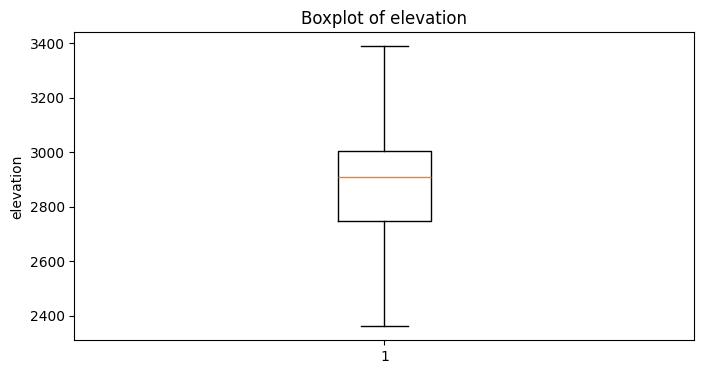

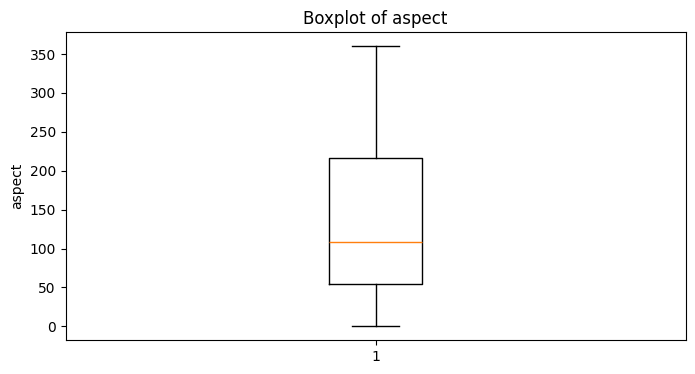

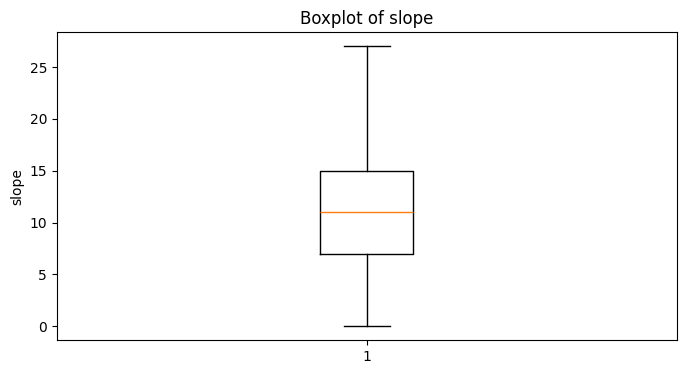

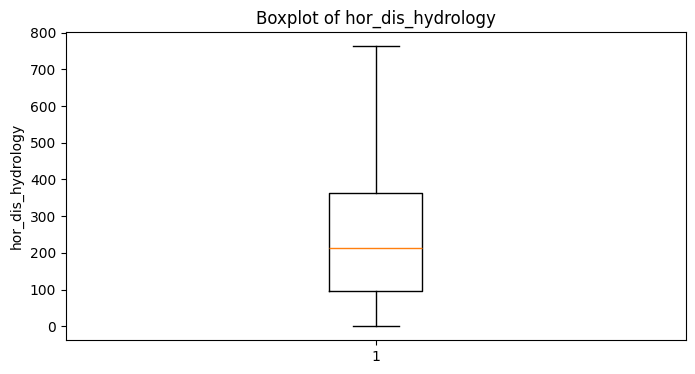

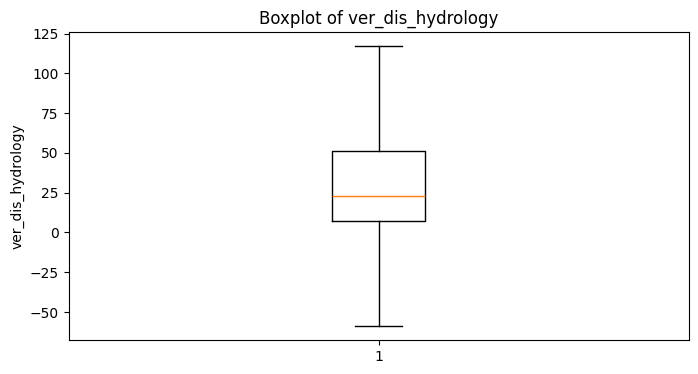

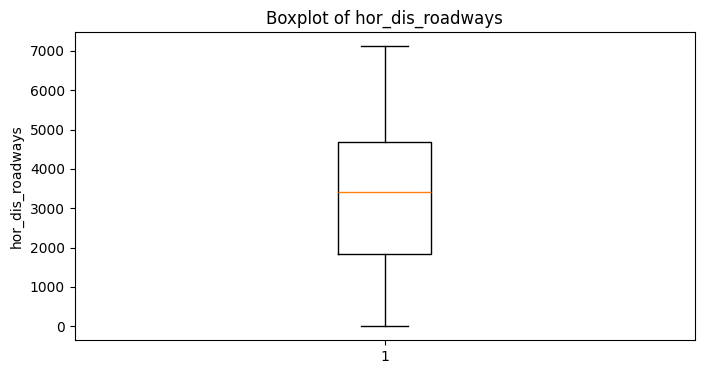

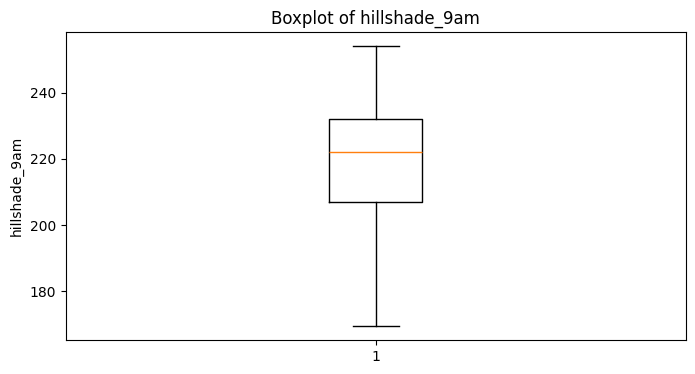

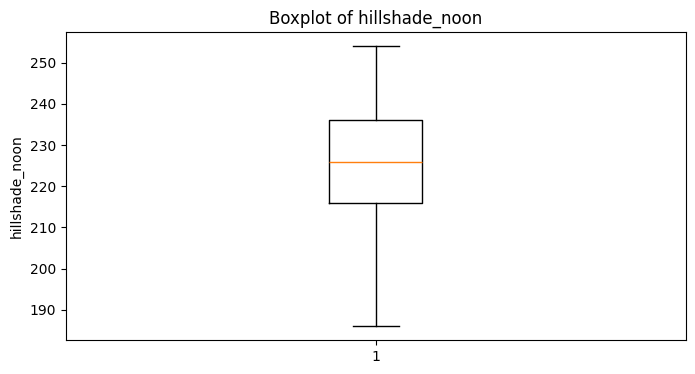

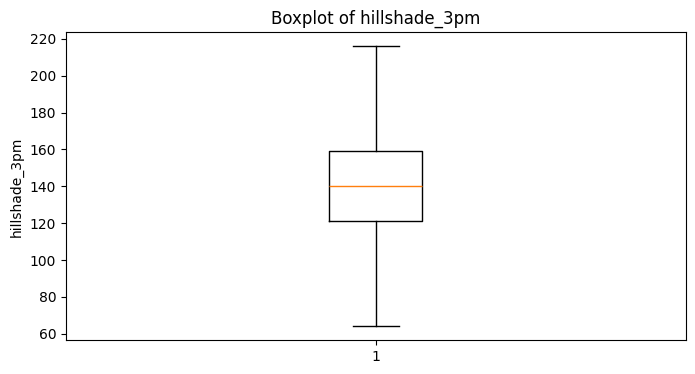

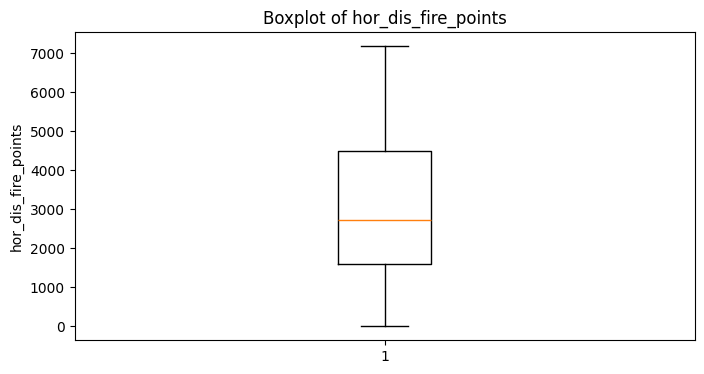

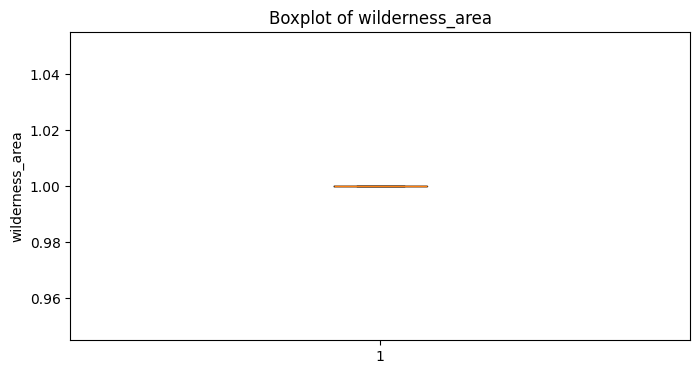

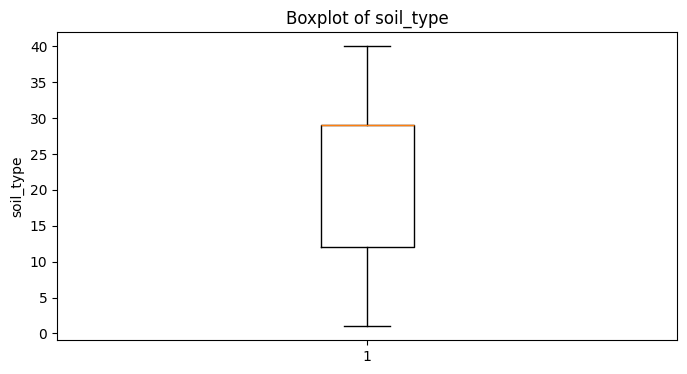

In [ ]:
cols =  ['elevation', 'aspect', 'slope', 'hor_dis_hydrology', 'ver_dis_hydrology', 'hor_dis_roadways', 'hillshade_9am', 'hillshade_noon', 'hillshade_3pm', 'hor_dis_fire_points', 'wilderness_area', 'soil_type']
for i in range(0, 12):
    plt.figure(figsize=(8, 4))
    plt.boxplot(df[cols[i]])
    plt.title(f"Boxplot of {cols[i]}")
    plt.ylabel(cols[i])
    plt.show()



In [ ]:
df.columns

Index(['elevation', 'aspect', 'slope', 'hor_dis_hydrology',
       'ver_dis_hydrology', 'hor_dis_roadways', 'hillshade_9am',
       'hillshade_noon', 'hillshade_3pm', 'hor_dis_fire_points', 'cover_type',
       'wilderness_area', 'soil_type'],
      dtype='object')

In [ ]:
continuous_cols = ['elevation', 'aspect', 'slope', 'hor_dis_hydrology',
       'ver_dis_hydrology', 'hor_dis_roadways', 'hillshade_9am',
       'hillshade_noon', 'hillshade_3pm', 'hor_dis_fire_points']


In [ ]:
import pandas as pd

skewness = df[continuous_cols].skew().sort_values(ascending=False)
print(skewness)

ver_dis_hydrology      0.861265
hor_dis_hydrology      0.792349
aspect                 0.689432
slope                  0.621361
hor_dis_fire_points    0.365249
hillshade_3pm         -0.001189
hor_dis_roadways      -0.058240
elevation             -0.340370
hillshade_noon        -0.505363
hillshade_9am         -0.740409
dtype: float64


In [ ]:
df[continuous_cols].skew()

,0
elevation,-0.340370
aspect,0.689432
slope,0.621361
hor_dis_hydrology,0.792349
ver_dis_hydrology,0.861265
hor_dis_roadways,-0.058240
hillshade_9am,-0.740409
hillshade_noon,-0.505363
hillshade_3pm,-0.001189
hor_dis_fire_points,0.365249


In [ ]:
import numpy as np
from scipy.stats import skew

for col in continuous_cols:
    if skew(df[col]) > 1:
        df[col] = np.log1p(df[col])

In [ ]:
from scipy.stats import skew

for col in continuous_cols:
    print(col, skew(df[col].dropna()))

elevation -0.34036614227436596
aspect 0.6894249007389325
slope 0.6213545167377653
hor_dis_hydrology 0.7923411304119377
ver_dis_hydrology 0.8612558748826841
hor_dis_roadways -0.058239023185711385
hillshade_9am -0.7404011441239379
hillshade_noon -0.5053573165325617
hillshade_3pm -0.0011886873468226107
hor_dis_fire_points 0.36524539429552005


In [ ]:
df[continuous_cols].skew()

,0
elevation,-0.340370
aspect,0.689432
slope,0.621361
hor_dis_hydrology,0.792349
ver_dis_hydrology,0.861265
hor_dis_roadways,-0.058240
hillshade_9am,-0.740409
hillshade_noon,-0.505363
hillshade_3pm,-0.001189
hor_dis_fire_points,0.365249


In [ ]:
import numpy as np

np.isinf(df['ver_dis_hydrology']).sum()
df['ver_dis_hydrology'].isna().sum()

np.int64(0)

Option 1: Yeo-Johnson

In [ ]:
from sklearn.preprocessing import PowerTransformer

pt = PowerTransformer(method='yeo-johnson')

df[['hor_dis_hydrology', 'ver_dis_hydrology']] = pt.fit_transform(
    df[['hor_dis_hydrology', 'ver_dis_hydrology']]
)

In [ ]:
df[continuous_cols].skew()

,0
elevation,-0.340370
aspect,0.689432
slope,0.621361
hor_dis_hydrology,-0.169816
ver_dis_hydrology,0.087352
hor_dis_roadways,-0.058240
hillshade_9am,-0.740409
hillshade_noon,-0.505363
hillshade_3pm,-0.001189
hor_dis_fire_points,0.365249


In [ ]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

num_cols = ['elevation', 'slope', 'hor_dis_hydrology',
            'ver_dis_hydrology', 'hor_dis_roadways',
            'hillshade_9am', 'hillshade_noon', 'hillshade_3pm',
            'hor_dis_fire_points']

df[num_cols] = scaler.fit_transform(df[num_cols])

In [ ]:
df.head(2)

,elevation,aspect,slope,hor_dis_hydrology,ver_dis_hydrology,hor_dis_roadways,hillshade_9am,hillshade_noon,hillshade_3pm,hor_dis_fire_points,cover_type,wilderness_area,soil_type
0,-1.422686,51,-1.469470,0.258124,-0.915049,-1.661258,0.15238,0.451589,0.264532,1.835567,Aspen,1.0,29
1,-1.452980,56,-1.636015,0.024593,-1.217221,-1.732357,0.10136,0.649543,0.363490,1.804918,Aspen,1.0,29


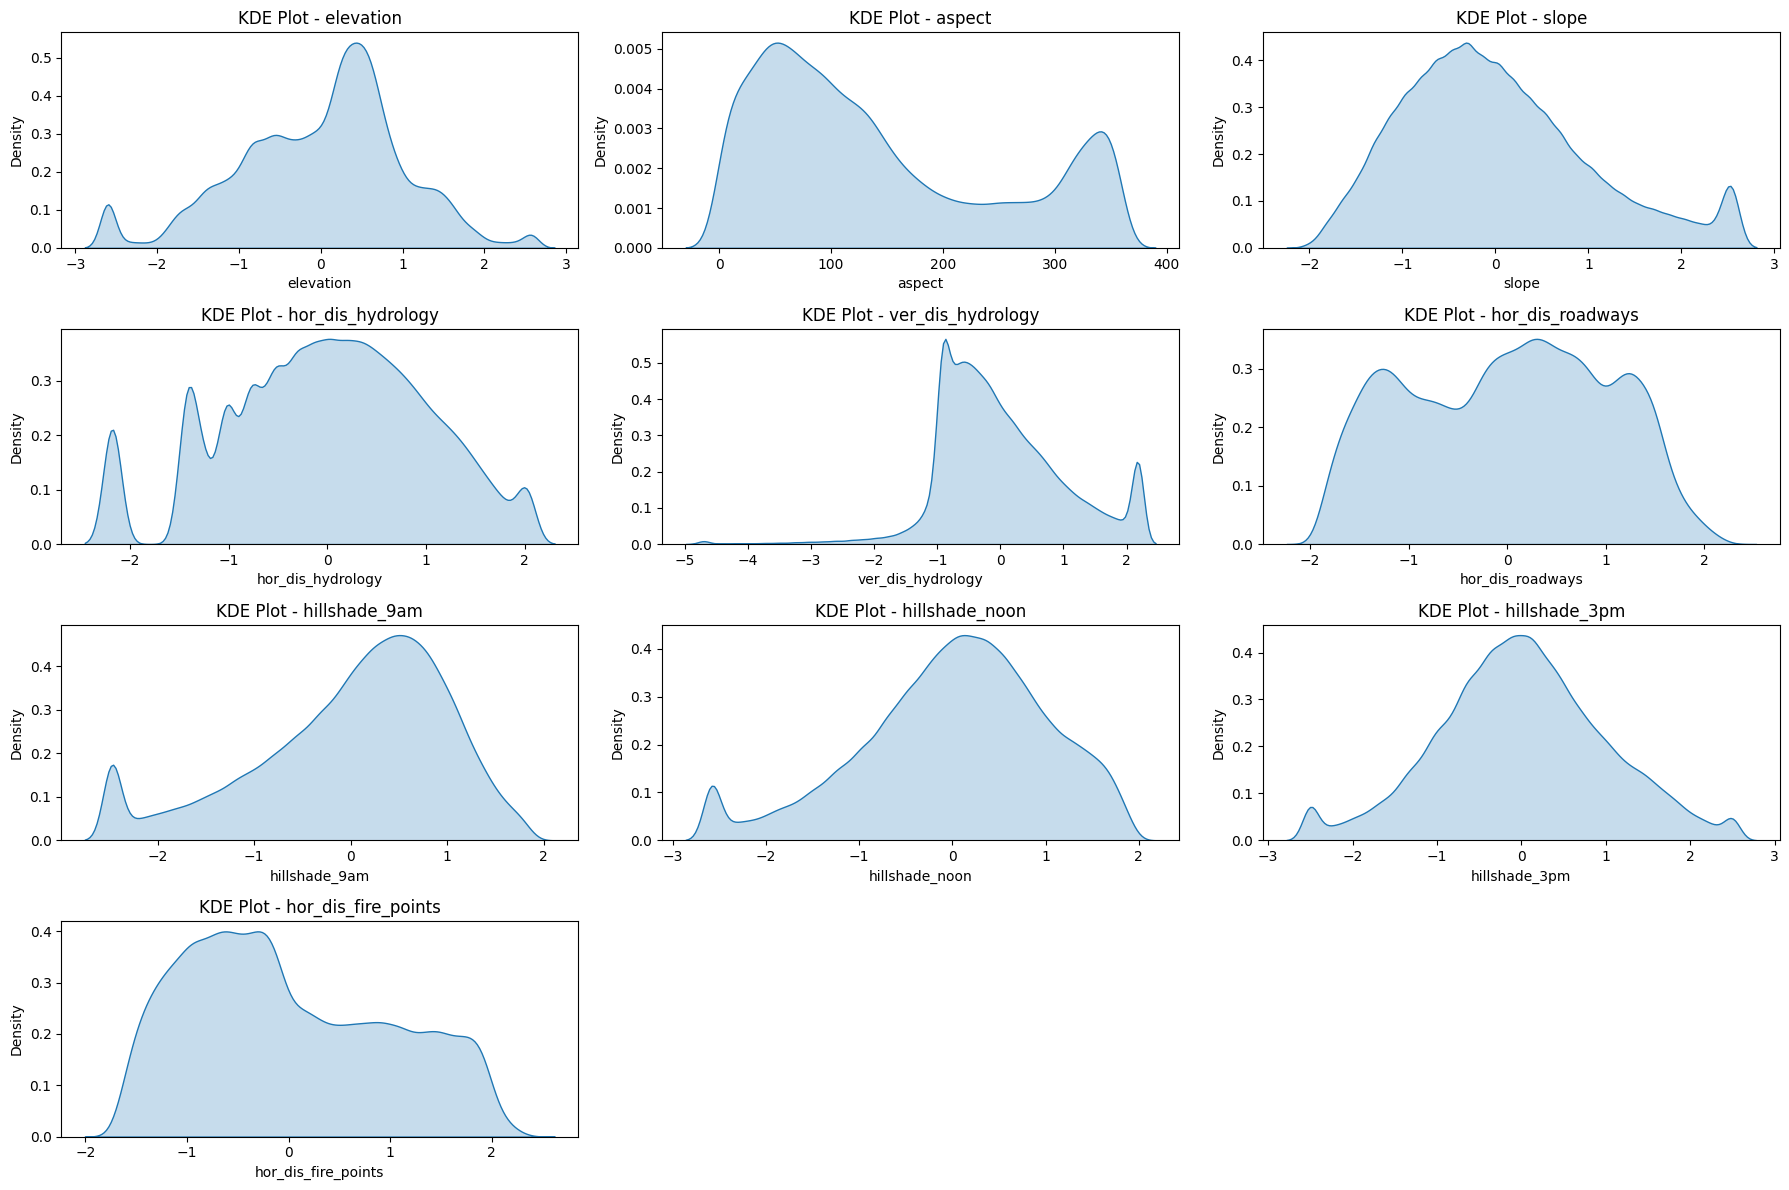

In [ ]:
num_cols = ['elevation', 'aspect', 'slope', 'hor_dis_hydrology', 'ver_dis_hydrology', 'hor_dis_roadways', 'hillshade_9am', 'hillshade_noon', 'hillshade_3pm', 'hor_dis_fire_points']

import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(18, 12))

for i, col in enumerate(num_cols, 1):
    plt.subplot(4, 3, i)
    sns.kdeplot(data=df, x=col, fill=True)
    plt.title(f"KDE Plot - {col}")

plt.tight_layout()
plt.show()


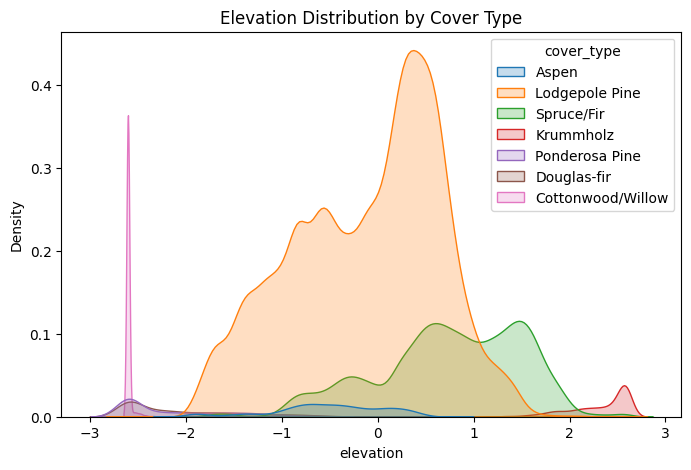

In [ ]:
plt.figure(figsize=(8, 5))
sns.kdeplot(data=df, x='elevation', hue='cover_type', fill=True)
plt.title("Elevation Distribution by Cover Type")
plt.show()

In [ ]:
df.columns

Index(['elevation', 'aspect', 'slope', 'hor_dis_hydrology',
       'ver_dis_hydrology', 'hor_dis_roadways', 'hillshade_9am',
       'hillshade_noon', 'hillshade_3pm', 'hor_dis_fire_points', 'cover_type',
       'wilderness_area', 'soil_type'],
      dtype='object')

4️⃣ Feature Engineering

In [ ]:
from sklearn.preprocessing import PowerTransformer

pt = PowerTransformer(method='yeo-johnson')
df[['hor_dis_hydrology', 'ver_dis_hydrology']] = pt.fit_transform(
    df[['hor_dis_hydrology', 'ver_dis_hydrology']]
)

In [ ]:
import numpy as np

df['aspect_sin'] = np.sin(np.radians(df['aspect']))
df['aspect_cos'] = np.cos(np.radians(df['aspect']))

In [ ]:
df['hydrology_distance'] = (df['hor_dis_hydrology']**2 + df['ver_dis_hydrology']**2) ** 0.5

In [ ]:
df['hillshade_mean'] = (
    df['hillshade_9am'] +
    df['hillshade_noon'] +
    df['hillshade_3pm']
) / 3

df['hillshade_diff'] = df['hillshade_3pm'] - df['hillshade_9am']

In [ ]:
df['elevation_slope'] = df['elevation'] * df['slope']

In [ ]:
df.head()

,elevation,aspect,slope,hor_dis_hydrology,ver_dis_hydrology,hor_dis_roadways,hillshade_9am,hillshade_noon,hillshade_3pm,hor_dis_fire_points,cover_type,wilderness_area,soil_type,aspect_sin,aspect_cos,hydrology_distance,hillshade_mean,hillshade_diff,elevation_slope
0,-1.422686,51,-1.469470,0.223470,-0.916250,-1.661258,0.152380,0.451589,0.264532,1.835567,Aspen,1.0,29,0.777146,0.629320,0.943108,0.289500,0.112152,2.090594
1,-1.452980,56,-1.636015,-0.013935,-1.243327,-1.732357,0.101360,0.649543,0.363490,1.804918,Aspen,1.0,29,0.829038,0.559193,1.243405,0.371464,0.262130,2.377097
2,-0.372506,139,-0.470197,0.272707,0.933755,-0.079292,0.815649,0.847497,-0.164286,1.745890,Lodgepole Pine,1.0,12,0.656059,-0.754710,0.972763,0.499620,-0.979935,0.175151
3,-0.468436,155,1.028712,0.143019,2.069054,-0.132617,1.019732,0.847497,-0.593104,1.796972,Lodgepole Pine,1.0,30,0.422618,-0.906308,2.073991,0.424708,-1.612836,-0.481885
4,-1.427735,45,-1.636015,-0.352204,-0.964536,-1.731765,0.101360,0.583558,0.330504,1.774836,Aspen,1.0,29,0.707107,0.707107,1.026829,0.338474,0.229144,2.335797


In [ ]:
df.columns

Index(['elevation', 'aspect', 'slope', 'hor_dis_hydrology',
       'ver_dis_hydrology', 'hor_dis_roadways', 'hillshade_9am',
       'hillshade_noon', 'hillshade_3pm', 'hor_dis_fire_points', 'cover_type',
       'wilderness_area', 'soil_type', 'aspect_sin', 'aspect_cos',
       'hydrology_distance', 'hillshade_mean', 'hillshade_diff',
       'elevation_slope'],
      dtype='object')

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 145890 entries, 0 to 145889
Data columns (total 19 columns):
 #   Column               Non-Null Count   Dtype  
---  ------               --------------   -----  
 0   elevation            145890 non-null  float64
 1   aspect               145890 non-null  int64  
 2   slope                145890 non-null  float64
 3   hor_dis_hydrology    145890 non-null  float64
 4   ver_dis_hydrology    145890 non-null  float64
 5   hor_dis_roadways     145890 non-null  float64
 6   hillshade_9am        145890 non-null  float64
 7   hillshade_noon       145890 non-null  float64
 8   hillshade_3pm        145890 non-null  float64
 9   hor_dis_fire_points  145890 non-null  float64
 10  cover_type           145890 non-null  object 
 11  wilderness_area      145890 non-null  float64
 12  soil_type            145890 non-null  int64  
 13  aspect_sin           145890 non-null  float64
 14  aspect_cos           145890 non-null  float64
 15  hydrology_distanc

In [ ]:
import numpy as np
import pandas as pd

def feature_engineering(df):
    df = df.copy()

    # -------------------------------
    # 1. Aspect transformation (IMPORTANT)
    # -------------------------------
    df['aspect_sin'] = np.sin(np.radians(df['aspect']))
    df['aspect_cos'] = np.cos(np.radians(df['aspect']))

    # -------------------------------
    # 2. Hydrology interaction
    # -------------------------------
    df['hydro_distance'] = np.sqrt(
        df['hor_dis_hydrology']**2 + df['ver_dis_hydrology']**2
    )

    # -------------------------------
    # 3. Elevation & slope interaction
    # -------------------------------
    df['elevation_slope'] = df['elevation'] * df['slope']

    # -------------------------------
    # 4. Hillshade combination
    # -------------------------------
    df['total_hillshade'] = (
        df['hillshade_9am'] +
        df['hillshade_noon'] +
        df['hillshade_3pm']
    )

    # -------------------------------
    # 5. Terrain roughness
    # -------------------------------
    df['terrain_roughness'] = df['elevation'] * df['slope'] / 100

    # -------------------------------
    # 6. Distance interaction
    # -------------------------------
    df['road_fire_ratio'] = df['hor_dis_roadways'] / (df['hor_dis_fire_points'] + 1)

    # -------------------------------
    # 7. Drop original aspect (optional)
    # -------------------------------
    df.drop(columns=['aspect'], inplace=True)

    return df

In [ ]:
df = feature_engineering(df)

Optionally create derived columns if required to improve model interpretability (like distance ratios or shade indices differences).

In [ ]:
df['hydrology_vs_road'] = df['hor_dis_hydrology'] / (df['hor_dis_roadways'] + 1)
df['fire_vs_road'] = df['hor_dis_fire_points'] / (df['hor_dis_roadways'] + 1)
df['hydrology_vs_fire'] = df['hor_dis_hydrology'] / (df['hor_dis_fire_points'] + 1)

In [ ]:
df['hydrology_slope_interaction'] = df['hydrology_distance'] * df['slope']

In [ ]:
df['elevation_normalized'] = (df['elevation'] - df['elevation'].mean()) / df['elevation'].std()
df['elevation_range_flag'] = (df['elevation'] > df['elevation'].median()).astype(int)

In [ ]:
df['hillshade_range'] = df[['hillshade_9am', 'hillshade_noon', 'hillshade_3pm']].max(axis=1) - \
                        df[['hillshade_9am', 'hillshade_noon', 'hillshade_3pm']].min(axis=1)

df['hillshade_ratio'] = df['hillshade_3pm'] / (df['hillshade_9am'] + 1)

In [ ]:
df['aspect_slope_sin'] = df['aspect_sin'] * df['slope']
df['aspect_slope_cos'] = df['aspect_cos'] * df['slope']

In [ ]:
df['terrain_ruggedness'] = df['slope'] * df['hillshade_diff']

In [ ]:
df['accessibility'] = 1 / (df['hor_dis_roadways'] + df['hor_dis_fire_points'] + 1)

In [ ]:
df['soil_wilderness'] = df['soil_type'].astype(str) + "_" + df['wilderness_area'].astype(str)

In [ ]:
df['soil_wilderness'] = df['soil_wilderness'].astype('float')

In [ ]:
df.head()

,elevation,slope,hor_dis_hydrology,ver_dis_hydrology,hor_dis_roadways,hillshade_9am,hillshade_noon,hillshade_3pm,hor_dis_fire_points,cover_type,...,soil_type_31,soil_type_32,soil_type_33,soil_type_34,soil_type_35,soil_type_36,soil_type_37,soil_type_38,soil_type_39,soil_type_40
0,-1.422686,-1.469470,0.223470,-0.916250,-1.661258,0.152380,0.451589,0.264532,1.835567,0,...,False,False,False,False,False,False,False,False,False,False
1,-1.452980,-1.636015,-0.013935,-1.243327,-1.732357,0.101360,0.649543,0.363490,1.804918,0,...,False,False,False,False,False,False,False,False,False,False
2,-0.372506,-0.470197,0.272707,0.933755,-0.079292,0.815649,0.847497,-0.164286,1.745890,4,...,False,False,False,False,False,False,False,False,False,False
3,-0.468436,1.028712,0.143019,2.069054,-0.132617,1.019732,0.847497,-0.593104,1.796972,4,...,False,False,False,False,False,False,False,False,False,False
4,-1.427735,-1.636015,-0.352204,-0.964536,-1.731765,0.101360,0.583558,0.330504,1.774836,0,...,False,False,False,False,False,False,False,False,False,False


In [ ]:
df['soil_wilderness'].dtypes

dtype('O')

In [ ]:
df.dtypes

,0
elevation,float64
slope,float64
hor_dis_hydrology,float64
ver_dis_hydrology,float64
hor_dis_roadways,float64
...,...
soil_type_36,bool
soil_type_37,bool
soil_type_38,bool
soil_type_39,bool


In [ ]:
df.tail(2)

,elevation,slope,hor_dis_hydrology,ver_dis_hydrology,hor_dis_roadways,hillshade_9am,hillshade_noon,hillshade_3pm,hor_dis_fire_points,cover_type,...,hydrology_slope_interaction,elevation_normalized,elevation_range_flag,hillshade_range,hillshade_ratio,aspect_slope_sin,aspect_slope_cos,terrain_ruggedness,accessibility,soil_wilderness
145888,-0.261429,-0.803288,0.775140,0.052611,-0.504705,0.713608,0.583558,-0.164286,-0.860990,Lodgepole Pine,...,-0.624094,-0.261428,0,0.877894,-0.095871,-0.688552,0.413724,0.705202,-2.734521,29_1.0
145889,-0.276576,0.029439,0.741238,-0.031048,-0.522480,1.070752,0.583558,-0.560118,-0.873477,Lodgepole Pine,...,0.021841,-0.276575,0,1.630871,-0.270490,0.021878,-0.019699,-0.048011,-2.525531,1_1.0


In [ ]:
import numpy as np
import pandas as pd

def create_interpretable_features(df):
    df = df.copy()

    # -----------------------------------
    # 1. Distance-based ratios
    # -----------------------------------
    df['road_to_fire_ratio'] = df['hor_dis_roadways'] / (df['hor_dis_fire_points'] + 1)
    df['water_to_road_ratio'] = df['hor_dis_hydrology'] / (df['hor_dis_roadways'] + 1)

    # -----------------------------------
    # 2. Hydrology relative position
    # -----------------------------------
    df['hydro_height_diff'] = df['ver_dis_hydrology']  # already meaningful
    df['hydro_combined_distance'] = np.sqrt(
        df['hor_dis_hydrology']**2 + df['ver_dis_hydrology']**2
    )

    # -----------------------------------
    # 3. Hillshade differences (very useful)
    # -----------------------------------
    df['shade_diff_morning_noon'] = df['hillshade_9am'] - df['hillshade_noon']
    df['shade_diff_noon_evening'] = df['hillshade_noon'] - df['hillshade_3pm']
    df['shade_range'] = df[['hillshade_9am','hillshade_noon','hillshade_3pm']].max(axis=1) - \
                        df[['hillshade_9am','hillshade_noon','hillshade_3pm']].min(axis=1)

    # -----------------------------------
    # 4. Shade index (overall sunlight)
    # -----------------------------------
    df['shade_mean'] = (
        df['hillshade_9am'] +
        df['hillshade_noon'] +
        df['hillshade_3pm']
    ) / 3

    # -----------------------------------
    # 5. Terrain interpretability features
    # -----------------------------------
    df['elevation_per_slope'] = df['elevation'] / (df['slope'] + 1)
    df['slope_intensity'] = df['slope'] / (df['elevation'] + 1)

    # -----------------------------------
    # 6. Accessibility index
    # -----------------------------------
    df['accessibility_index'] = (
        df['hor_dis_roadways'] + df['hor_dis_fire_points']
    ) / 2

    # -----------------------------------
    # 7. Water proximity index
    # -----------------------------------
    df['water_proximity'] = 1 / (df['hor_dis_hydrology'] + 1)

    return df

In [ ]:
df = create_interpretable_features(df)

In [ ]:
df

,elevation,slope,hor_dis_hydrology,ver_dis_hydrology,hor_dis_roadways,hillshade_9am,hillshade_noon,hillshade_3pm,hor_dis_fire_points,cover_type,...,hydro_height_diff,hydro_combined_distance,shade_diff_morning_noon,shade_diff_noon_evening,shade_range,shade_mean,elevation_per_slope,slope_intensity,accessibility_index,water_proximity
0,-1.422686,-1.469470,0.223470,-0.916250,-1.661258,0.152380,0.451589,0.264532,1.835567,Aspen,...,-0.916250,0.943108,-0.299209,0.187057,0.299209,0.289500,3.030409,3.476504,0.087155,0.817347
1,-1.452980,-1.636015,-0.013935,-1.243327,-1.732357,0.101360,0.649543,0.363490,1.804918,Aspen,...,-1.243327,1.243405,-0.548183,0.286053,0.548183,0.371464,2.284504,3.611675,0.036280,1.014132
2,-0.372506,-0.470197,0.272707,0.933755,-0.079292,0.815649,0.847497,-0.164286,1.745890,Lodgepole Pine,...,0.933755,0.972763,-0.031848,1.011783,1.011783,0.499620,-0.703102,-0.749325,0.833299,0.785727
3,-0.468436,1.028712,0.143019,2.069054,-0.132617,1.019732,0.847497,-0.593104,1.796972,Lodgepole Pine,...,2.069054,2.073991,0.172235,1.440601,1.612836,0.424708,-0.230903,1.935253,0.832177,0.874876
4,-1.427735,-1.636015,-0.352204,-0.964536,-1.731765,0.101360,0.583558,0.330504,1.774836,Aspen,...,-0.964536,1.026829,-0.482199,0.253054,0.482199,0.338474,2.244812,3.824834,0.021536,1.543695
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
145885,-0.221037,-0.636743,0.762463,0.422665,-0.451380,0.713608,0.121666,-0.395188,-0.822962,Lodgepole Pine,...,0.422665,0.871777,0.591942,0.516854,1.108796,0.146695,-0.608487,-0.817424,-0.637171,0.567388
145886,-0.231135,-1.302925,0.821257,0.422665,-0.469155,0.305442,0.385604,0.066616,-0.836017,Lodgepole Pine,...,0.422665,0.923639,-0.080162,0.318989,0.318989,0.252554,0.763012,-1.694608,-0.652586,0.549071
145887,-0.246282,-0.803288,0.821257,0.134537,-0.486930,0.560546,0.187651,-0.230258,-0.848503,Lodgepole Pine,...,0.134537,0.832204,0.372895,0.417909,0.790804,0.172646,-1.251994,-1.065767,-0.667717,0.549071
145888,-0.261429,-0.803288,0.775140,0.052611,-0.504705,0.713608,0.583558,-0.164286,-0.860990,Lodgepole Pine,...,0.052611,0.776924,0.130049,0.747844,0.877894,0.377627,-1.328994,-1.087625,-0.682847,0.563336


In [ ]:
df.to_csv(r'fedata.csv', index=False)

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 145890 entries, 0 to 145889
Data columns (total 47 columns):
 #   Column                       Non-Null Count   Dtype  
---  ------                       --------------   -----  
 0   elevation                    145890 non-null  float64
 1   slope                        145890 non-null  float64
 2   hor_dis_hydrology            145890 non-null  float64
 3   ver_dis_hydrology            145890 non-null  float64
 4   hor_dis_roadways             145890 non-null  float64
 5   hillshade_9am                145890 non-null  float64
 6   hillshade_noon               145890 non-null  float64
 7   hillshade_3pm                145890 non-null  float64
 8   hor_dis_fire_points          145890 non-null  float64
 9   cover_type                   145890 non-null  object 
 10  wilderness_area              145890 non-null  float64
 11  soil_type                    145890 non-null  int64  
 12  aspect_sin                   145890 non-null  float64
 13 

In [ ]:
num_cols = [
    'elevation', 'aspect', 'slope', 'hor_dis_hydrology', 'ver_dis_hydrology',
    'hor_dis_roadways', 'hillshade_9am', 'hillshade_noon', 'hillshade_3pm',
    'hor_dis_fire_points', 'cover_type', 'wilderness_area',
    'hydrology_distance', 'hillshade_mean', 'hillshade_diff',
    'hydrology_vs_road', 'fire_vs_road', 'hydrology_vs_fire',
    'hydrology_slope_interaction', 'elevation_normalized',
    'elevation_range_flag', 'hillshade_range', 'hillshade_ratio',
    'aspect_slope_sin', 'aspect_slope_cos', 'terrain_ruggedness',
    'accessibility', 'soil_wilderness',
    'elevation_slope', 'aspect_sin', 'aspect_cos'
]

In [ ]:
cat_cols = ['wilderness_area']

In [ ]:
'''plt.figure(figsize=(22, 28))
plt.suptitle('Univariate Analysis of Categorical Features', fontsize=20, fontweight='bold', alpha=0.8, y=1.)
for i, col in enumerate(num_cols):
    plt.subplot(9, 4, i+1)
    sns.histplot(df[num_cols], bins=30, kde=True)
    plt.title(col)
    #plt.tight_layout()
    plt.show()'''

"plt.figure(figsize=(22, 28))\nplt.suptitle('Univariate Analysis of Categorical Features', fontsize=20, fontweight='bold', alpha=0.8, y=1.)\nfor i, col in enumerate(num_cols):\n    plt.subplot(9, 4, i+1)\n    sns.histplot(df[num_cols], bins=30, kde=True)\n    plt.title(col)\n    #plt.tight_layout()\n    plt.show()"

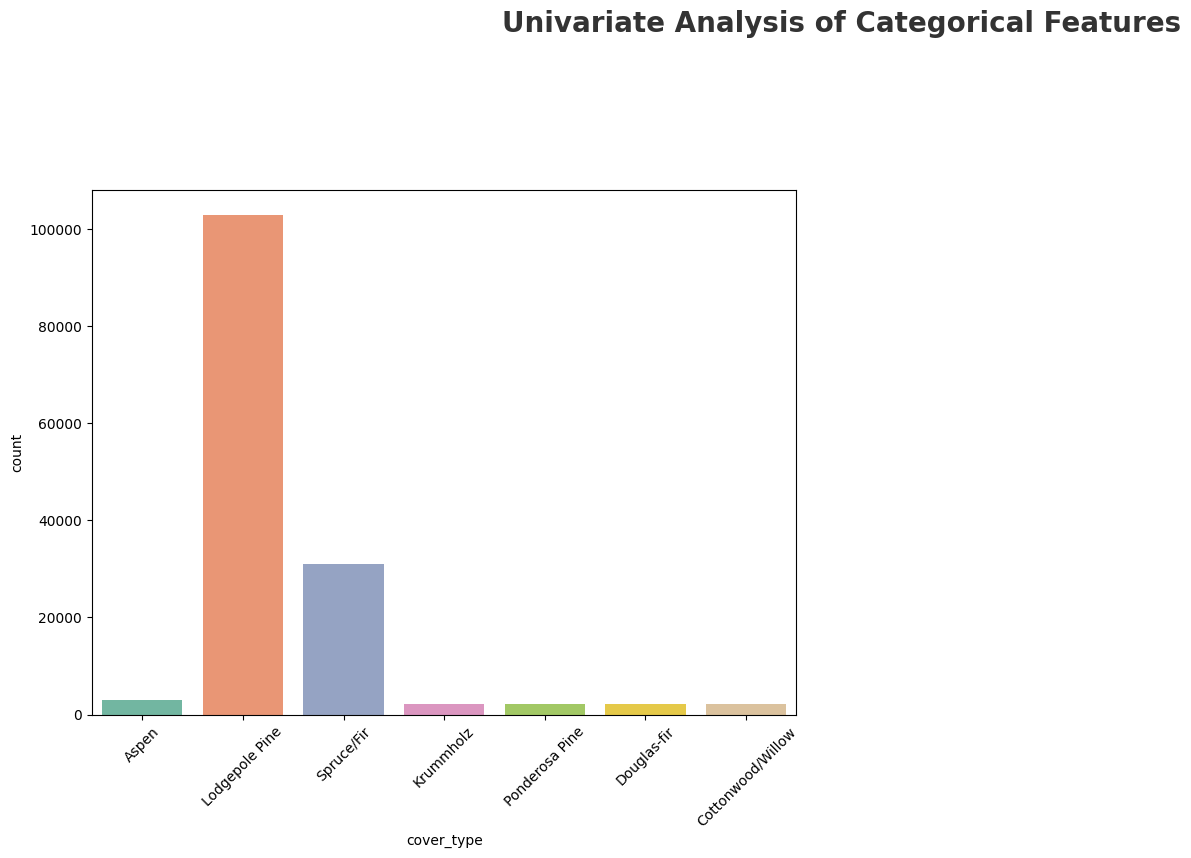

In [ ]:
# categorical columns
plt.figure(figsize=(20, 15))
plt.suptitle('Univariate Analysis of Categorical Features', fontsize=20, fontweight='bold', alpha=0.8, y=1.)
category = ['cover_type']
for i in range(0, len(category)):
    plt.subplot(2, 2, i+1)
    sns.countplot(x=df[category[i]],palette="Set2")
    plt.xlabel(category[i])
    plt.xticks(rotation=45)
    #plt.tight_layout()
    plt.show()


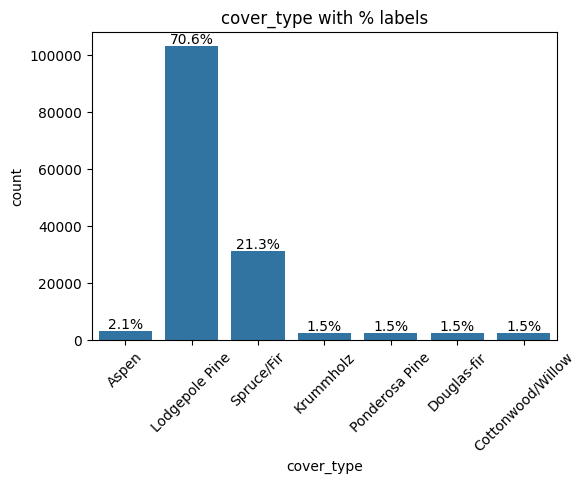

In [ ]:
import numpy as np

col = 'cover_type'
fig, ax = plt.subplots(figsize=(6,4))

sns.countplot(x=df[col], ax=ax)

total = len(df[col])
for p in ax.patches:
    percentage = f'{100 * p.get_height()/total:.1f}%'
    ax.annotate(percentage,
                (p.get_x() + p.get_width() / 2., p.get_height()),
                ha='center', va='bottom')

plt.title(f'{col} with % labels')
plt.xticks(rotation=45)
plt.show()

Ensure that all categorical columns are encoded before training the model.




In [ ]:
print(df['soil_type'].nunique())

39


In [ ]:
print(df.dtypes)

elevation                      float64
slope                          float64
hor_dis_hydrology              float64
ver_dis_hydrology              float64
hor_dis_roadways               float64
hillshade_9am                  float64
hillshade_noon                 float64
hillshade_3pm                  float64
hor_dis_fire_points            float64
cover_type                      object
wilderness_area                float64
soil_type                        int64
aspect_sin                     float64
aspect_cos                     float64
hydrology_distance             float64
hillshade_mean                 float64
hillshade_diff                 float64
elevation_slope                float64
hydro_distance                 float64
total_hillshade                float64
terrain_roughness              float64
road_fire_ratio                float64
hydrology_vs_road              float64
fire_vs_road                   float64
hydrology_vs_fire              float64
hydrology_slope_interacti

In [ ]:
X = pd.get_dummies(
    df.drop('cover_type', axis=1),
    columns=['wilderness_area', 'soil_type'],
    drop_first=True
)

y = df['cover_type']

In [ ]:
from sklearn.preprocessing import LabelEncoder

if df['cover_type'].dtype == 'object':
    le = LabelEncoder()
    df['cover_type'] = le.fit_transform(df['cover_type'])

In [ ]:
df = pd.get_dummies(df, columns=['soil_type'], drop_first=True)

In [ ]:
df.columns

Index(['elevation', 'slope', 'hor_dis_hydrology', 'ver_dis_hydrology',
       'hor_dis_roadways', 'hillshade_9am', 'hillshade_noon', 'hillshade_3pm',
       'hor_dis_fire_points', 'cover_type', 'wilderness_area', 'aspect_sin',
       'aspect_cos', 'hydrology_distance', 'hillshade_mean', 'hillshade_diff',
       'elevation_slope', 'hydro_distance', 'total_hillshade',
       'terrain_roughness', 'road_fire_ratio', 'hydrology_vs_road',
       'fire_vs_road', 'hydrology_vs_fire', 'hydrology_slope_interaction',
       'elevation_normalized', 'elevation_range_flag', 'hillshade_range',
       'hillshade_ratio', 'aspect_slope_sin', 'aspect_slope_cos',
       'terrain_ruggedness', 'accessibility', 'soil_wilderness',
       'road_to_fire_ratio', 'water_to_road_ratio', 'hydro_height_diff',
       'hydro_combined_distance', 'shade_diff_morning_noon',
       'shade_diff_noon_evening', 'shade_range', 'shade_mean',
       'elevation_per_slope', 'slope_intensity', 'accessibility_index',
       'water_

In [ ]:
df.head()

,elevation,slope,hor_dis_hydrology,ver_dis_hydrology,hor_dis_roadways,hillshade_9am,hillshade_noon,hillshade_3pm,hor_dis_fire_points,cover_type,...,soil_type_31,soil_type_32,soil_type_33,soil_type_34,soil_type_35,soil_type_36,soil_type_37,soil_type_38,soil_type_39,soil_type_40
0,-1.422686,-1.469470,0.223470,-0.916250,-1.661258,0.152380,0.451589,0.264532,1.835567,0,...,False,False,False,False,False,False,False,False,False,False
1,-1.452980,-1.636015,-0.013935,-1.243327,-1.732357,0.101360,0.649543,0.363490,1.804918,0,...,False,False,False,False,False,False,False,False,False,False
2,-0.372506,-0.470197,0.272707,0.933755,-0.079292,0.815649,0.847497,-0.164286,1.745890,4,...,False,False,False,False,False,False,False,False,False,False
3,-0.468436,1.028712,0.143019,2.069054,-0.132617,1.019732,0.847497,-0.593104,1.796972,4,...,False,False,False,False,False,False,False,False,False,False
4,-1.427735,-1.636015,-0.352204,-0.964536,-1.731765,0.101360,0.583558,0.330504,1.774836,0,...,False,False,False,False,False,False,False,False,False,False


In [ ]:
from sklearn.preprocessing import OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.ensemble import RandomForestClassifier

# -----------------------------
# Define X and y
# -----------------------------
X = df.drop('cover_type', axis=1)
y = df['cover_type']

# -----------------------------
# Only wilderness_area is categorical
# -----------------------------
categorical_cols = ['wilderness_area']

preprocessor = ColumnTransformer(
    transformers=[
        ('cat', OneHotEncoder(handle_unknown='ignore'), categorical_cols)
    ],
    remainder='passthrough'  # keep all other columns
)

pipeline = Pipeline([
    ('preprocessor', preprocessor),
    ('model', RandomForestClassifier(random_state=42))
])

# Train
pipeline.fit(X, y)

Pipeline(steps=[('preprocessor',
                 ColumnTransformer(remainder='passthrough',
                                   transformers=[('cat',
                                                  OneHotEncoder(handle_unknown='ignore'),
                                                  ['wilderness_area'])])),
                ('model', RandomForestClassifier(random_state=42))])

In [ ]:
from sklearn.ensemble import RandomForestClassifier

X = df.drop('cover_type', axis=1)
y = df['cover_type']

model = RandomForestClassifier(random_state=42)
model.fit(X, y)

RandomForestClassifier(random_state=42)

The same encoder must be saved (using pickle or joblib) and reused during
inference to maintain consistency between training and prediction.


In [ ]:
import joblib
from sklearn.preprocessing import OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.ensemble import RandomForestClassifier

# -----------------------------
# 1. Define X and y
# -----------------------------
X = df.drop('cover_type', axis=1)
y = df['cover_type']

# -----------------------------
# 2. Define categorical columns
# (only if needed)
# -----------------------------
categorical_cols = ['wilderness_area']  # remove if already numeric

# -----------------------------
# 3. Preprocessing
# -----------------------------
preprocessor = ColumnTransformer(
    transformers=[
        ('cat', OneHotEncoder(handle_unknown='ignore'), categorical_cols)
    ],
    remainder='passthrough'
)

# -----------------------------
# 4. Pipeline
# -----------------------------
pipeline = Pipeline([
    ('preprocessor', preprocessor),
    ('model', RandomForestClassifier(random_state=42))
])

# -----------------------------
# 5. Train
# -----------------------------
pipeline.fit(X, y)

# -----------------------------
# 6. Save FULL pipeline ✅
# -----------------------------
joblib.dump(pipeline, "full_pipeline.pkl")

['full_pipeline.pkl']

In [ ]:
pipeline = Pipeline([
    ('preprocessing', preprocessor),
    ('model', RandomForestClassifier())
])

In [ ]:
X = df.drop('cover_type', axis=1)
y = df['cover_type']

# optional encoding
X = pd.get_dummies(X)

from sklearn.pipeline import Pipeline
from sklearn.ensemble import RandomForestClassifier

pipeline = Pipeline([
    ('model', RandomForestClassifier())
])

pipeline.fit(X, y)

Pipeline(steps=[('model', RandomForestClassifier())])

In [ ]:
X = df.drop('cover_type', axis=1)
y = df['cover_type']

# encode
X = pd.get_dummies(X)

# split
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X, y)

# align columns
X_test = X_test.reindex(columns=X_train.columns, fill_value=0)

In [ ]:
joblib.dump(pipeline, 'model_pipeline.pkl')

['model_pipeline.pkl']

● Plot feature importances after baseline model fitting for interpretability.

---




In [ ]:
importance = model.feature_importances_

# Ensure matching feature names
feature_names = X.columns

print("Feature count:", len(feature_names))
print("Importance count:", len(importance))

# Fix if mismatch
min_len = min(len(feature_names), len(importance))

importance_df = pd.DataFrame({
    'feature': feature_names[:min_len],
    'importance': importance[:min_len]
})

importance_df = importance_df.sort_values(by='importance', ascending=False)

print(importance_df.head(10))

Feature count: 121
Importance count: 83
                 feature  importance
24  elevation_normalized    0.113003
0              elevation    0.096485
43       water_proximity    0.051826
4       hor_dis_roadways    0.047493
32    road_to_fire_ratio    0.045264
31         accessibility    0.044682
8    hor_dis_fire_points    0.039144
21          fire_vs_road    0.038718
33   water_to_road_ratio    0.034667
19       road_fire_ratio    0.034618


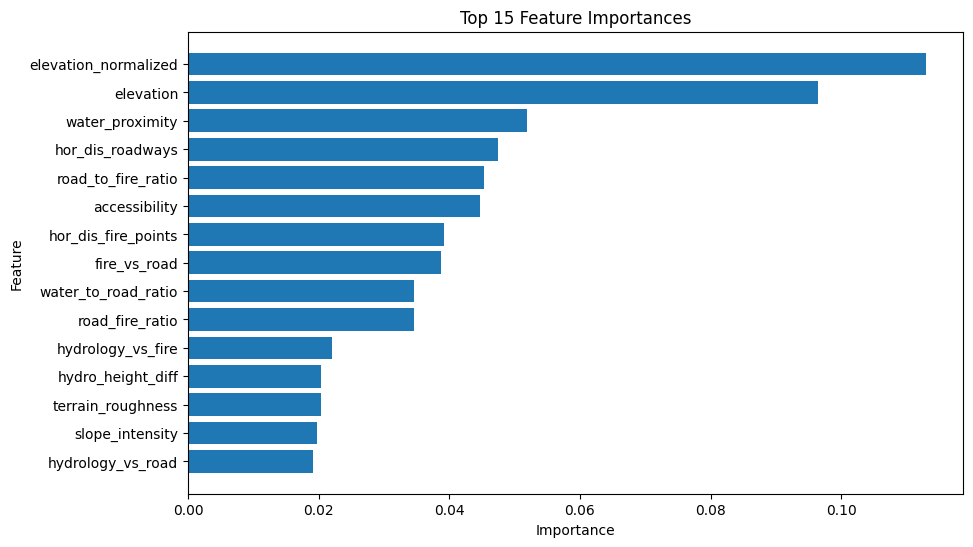

In [ ]:
plt.figure(figsize=(10,6))

top_features = importance_df.head(15)

plt.barh(top_features['feature'], top_features['importance'])
plt.xlabel("Importance")
plt.ylabel("Feature")
plt.title("Top 15 Feature Importances")

plt.gca().invert_yaxis()  # highest on top
plt.show()

Class Imbalance Handling

---


Use RandomOverSampler or SMOTE or other resampling techniques to balance class distribution in the training data

In [ ]:
y.value_counts(normalize=True)

,proportion
cover_type,
4,0.706498
6,0.213243
0,0.021036
3,0.014806
5,0.014806
2,0.014806
1,0.014806


In [ ]:
from sklearn.model_selection import train_test_split

X = df.drop('cover_type', axis=1)
y = df['cover_type']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

In [ ]:
from imblearn.over_sampling import RandomOverSampler
from imblearn.over_sampling import SMOTE
from imblearn.combine import SMOTETomek

# Random Over Sampling
ros = RandomOverSampler(random_state=42)
X_ros, y_ros = ros.fit_resample(X_train, y_train)

# SMOTE
smote = SMOTE(random_state=42)
X_smote, y_smote = smote.fit_resample(X_train, y_train)

# SMOTETomek
smt = SMOTETomek(random_state=42)
X_smt, y_smt = smt.fit_resample(X_train, y_train)

In [ ]:
#y_train_res.value_counts()

In [ ]:
#.1
from sklearn.ensemble import RandomForestClassifier

model = RandomForestClassifier(random_state=42)
model.fit(X_train_res, y_train_res)

NameError: name 'X_train_res' is not defined

In [ ]:
#2
from sklearn.metrics import classification_report

y_pred = model.predict(X_test)
print(classification_report(y_test, y_pred))

In [ ]:
3#
model = RandomForestClassifier(class_weight='balanced')

Feature Selection


1. Feature Importance using Random Forest

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.ensemble import RandomForestClassifier

# Train baseline model
rf = RandomForestClassifier(random_state=42)
rf.fit(X_train, y_train)

# Get importance
importance = rf.feature_importances_
feature_names = X_train.columns

# Create DataFrame
importance_df = pd.DataFrame({
    'feature': feature_names,
    'importance': importance
}).sort_values(by='importance', ascending=False)

# Show top 10
print(importance_df.head(10))

                 feature  importance
24  elevation_normalized    0.106724
0              elevation    0.100898
43   accessibility_index    0.049789
4       hor_dis_roadways    0.047766
31         accessibility    0.045378
32       soil_wilderness    0.043533
21          fire_vs_road    0.040021
8    hor_dis_fire_points    0.038350
33    road_to_fire_ratio    0.035539
19       road_fire_ratio    0.033045


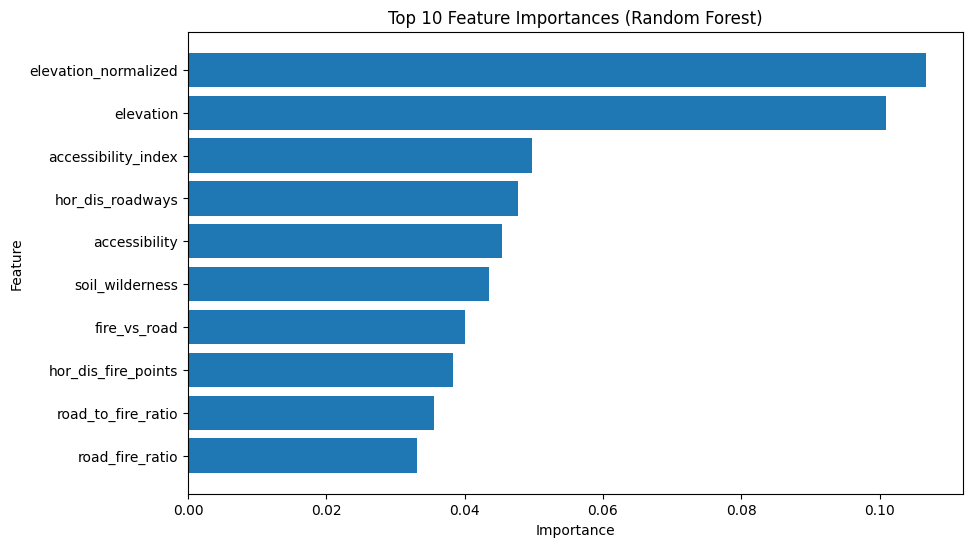

In [ ]:
plt.figure(figsize=(10,6))
plt.barh(importance_df['feature'][:10], importance_df['importance'][:10])
plt.xlabel("Importance")
plt.ylabel("Feature")
plt.title("Top 10 Feature Importances (Random Forest)")
plt.gca().invert_yaxis()
plt.show()

2. Correlation-based Feature Analysis

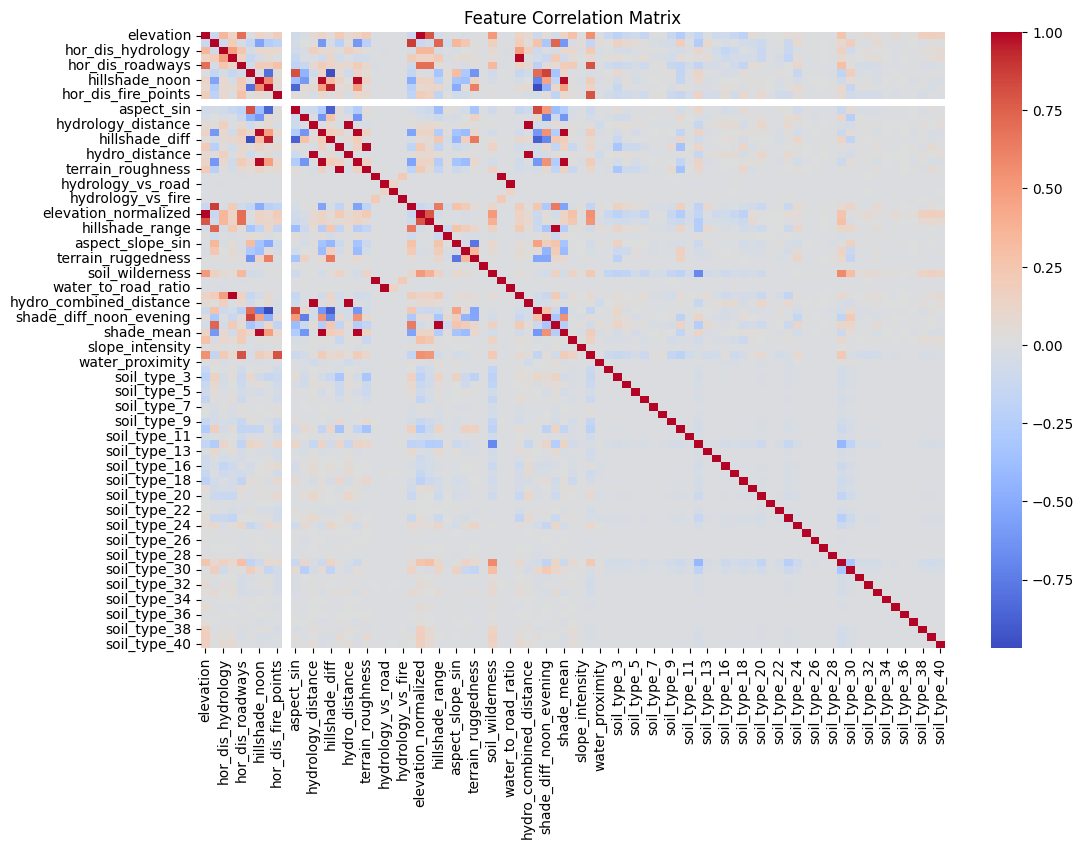

In [ ]:
import seaborn as sns

corr_matrix = X_train.corr()

plt.figure(figsize=(12,8))
sns.heatmap(corr_matrix, cmap='coolwarm')
plt.title("Feature Correlation Matrix")
plt.show()

In [ ]:
import numpy as np

# Set threshold
threshold = 0.9

# Get upper triangle
upper = corr_matrix.where(np.triu(np.ones(corr_matrix.shape), k=1).astype(bool))

# Find columns to drop
to_drop = [column for column in upper.columns if any(upper[column] > threshold)]

print("Highly correlated features to drop:")
print(to_drop)

# Drop them
X_train_corr = X_train.drop(columns=to_drop)
X_test_corr = X_test.drop(columns=to_drop)

Highly correlated features to drop:
['hillshade_mean', 'hillshade_diff', 'hydro_distance', 'total_hillshade', 'terrain_roughness', 'elevation_normalized', 'road_to_fire_ratio', 'water_to_road_ratio', 'hydro_height_diff', 'hydro_combined_distance', 'shade_range', 'shade_mean']


Drop less relevant or low-variance features to simplify the model and improve training efficiency.

In [ ]:
from sklearn.feature_selection import VarianceThreshold

# Set threshold (0 removes constant features, 0.01 removes near-constant)
selector = VarianceThreshold(threshold=0.01)

# Fit on training data
X_train_var = selector.fit_transform(X_train)
X_test_var = selector.transform(X_test)

# Get selected feature names
selected_features = X_train.columns[selector.get_support()]

# Convert back to DataFrame
import pandas as pd
X_train_var = pd.DataFrame(X_train_var, columns=selected_features)
X_test_var = pd.DataFrame(X_test_var, columns=selected_features)

print("Remaining features:", len(selected_features))

Remaining features: 52


In [ ]:
from sklearn.ensemble import RandomForestClassifier
import pandas as pd

# Train model
rf = RandomForestClassifier(random_state=42)
rf.fit(X_train, y_train)

# Get importance
importance = rf.feature_importances_

importance_df = pd.DataFrame({
    'feature': X_train.columns,
    'importance': importance
})

# Set threshold (tune this)
threshold = 0.01

# Select important features
selected_features = importance_df[importance_df['importance'] > threshold]['feature']

# Filter dataset
X_train_imp = X_train[selected_features]
X_test_imp = X_test[selected_features]

print("Selected features:", len(selected_features))

Selected features: 29


In [ ]:
import numpy as np

corr_matrix = X_train.corr().abs()

upper = corr_matrix.where(np.triu(np.ones(corr_matrix.shape), k=1).astype(bool))

to_drop = [col for col in upper.columns if any(upper[col] > 0.9)]

X_train_corr = X_train.drop(columns=to_drop)
X_test_corr = X_test.drop(columns=to_drop)

print("Dropped features:", len(to_drop))

Dropped features: 13


In [ ]:
print("Before:", X.shape)
print("After:", X.shape)

Before: (145890, 83)
After: (145890, 83)


In [ ]:
from sklearn.model_selection import cross_val_score

score = cross_val_score(rf, X, y, cv=5)
print(score.mean())

0.7519500993899513


In [ ]:
df.to_csv('data_final.csv', index=False)

Model Building